## Step 1: Research Question
How do PM2.5 and NO2 levels in Berlin (Germany) and London (United Kingdom)compare across winter and summer seasons in 2024, and what trends emerge during the peak population periods?

## Step 2: Data Retrieval from OpenAQ
In this step, we will retrieve data for the chosen cities from the OpenAQ website with the Url given.
- Step 1: Create an account on https://api.openaq.org to get an Api key
- Step 2: From the Explore Data section, search for cities of interest for those with particulate matter (PM2.5) and  Nitrogen Dioxide(NO2). We found two cities, Berlin in Germany and London in the UK with both PM2.5 and NO2
- We will import all libraries needed for this analysis, from requests to scrape data from the website to the matplotlib library for visualizations and other essential libraries.

In [3]:
%matplotlib inline

In [4]:
#Here we import all the needed libraries
import requests
import pandas as pd
from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pandas import json_normalize
from datetime import datetime


In [5]:
#Variable initialization
#we assign the api key to a variable api_key as a placeholder
#we store the api key in a dictionary as a key_pair
api_key =  "YOUR_API_KEY_HERE"
headers = {"X-API-Key": api_key}


In [6]:
# Coordinates: Berlin city centre, London city centre
#we create a nested dictionary of cities with Berlin having its latitude and longitude
#and London having its own latitude and longitude
cities = {
    "Berlin": {"lat": 52.5200, "lon": 13.4050},
    "London": {"lat": 51.5074, "lon": -0.1278}
}

In [7]:
#We loop through the cities dictionary because we want to retrieve the data for both cities using the coordinates

for city, coords in cities.items():
    url = (
        f"https://api.openaq.org/v3/locations"
        f"?coordinates={coords['lat']},{coords['lon']}"
        f"&radius=15000&limit=10"
    )

In [8]:
#use request to fetch the data for both cities
#we will use the json_normalize() function to flatten the data inorder to retrieve a dataframe that can be used for our analysis
response = requests.get(url, headers=headers)
df = json_normalize(response.json()["results"])
print(f"\n=== {city} ===")


=== London ===


The result only shows London whcih means we could not retrieve the data for Berlin, let us check with the print function to print the dataframe with some column headers to view. The result is shown below: 

In [10]:
#we want to view the dataframe to investigate the table, we will use the to_string() function to convert all data types to string
print(df[["id", "name", "locality", "country.name"]].to_string())

    id                                          name                locality    country.name
0   60                  Haringey Roadside - UKA00260                Haringey  United Kingdom
1  146         Southwark A2 Old Kent Road - UKA00558               Southwark  United Kingdom
2  148                  London Bloomsbury - UKA00211                  Camden  United Kingdom
3  149                              Ealing Horn Lane                  London  United Kingdom
4  150  London Haringey Priory Park South - UKA00568                  London  United Kingdom
5  151                 Tower Hamlets - Mile End Road           Tower Hamlets  United Kingdom
6  152                    Camden Kerbside - UKA00259                  Camden  United Kingdom
7  154             London Marylebone Road - UKA00315             Westminster  United Kingdom
8  155               London N. Kensington - UKA00253  Kensington and Chelsea  United Kingdom
9  159                 London Westminster - UKA00435                  

In [11]:
#The result of the above shows only London data, I could not retrieve Berlin's data so I had to try a larger radius for the coordinates
berlin_url = (
    "https://api.openaq.org/v3/locations"
    "?coordinates=52.5200,13.4050"
    "&radius=25000&limit=10"
)
response = requests.get(berlin_url, headers=headers)
df_berlin = json_normalize(response.json()["results"])
print(df_berlin[["id", "name", "locality", "country.name"]].to_string())

     id                      name             locality country.name
0  2993           Berlin Neukölln               Berlin      Germany
1  3017         Berlin Karlshorst               Berlin      Germany
2  3019              Berlin Mitte               Berlin      Germany
3  3021                   DEBE064                 None      Germany
4  3025                   DEBE063               Berlin      Germany
5  3026         Berlin Schöneberg               Berlin      Germany
6  3070     Bernau, Lohmühlenstr.    Bernau bei Berlin      Germany
7  3096   Potsdam, Groß Glienicke              Potsdam      Germany
8  4582  Berlin Grunewald (3.5 m)               Berlin      Germany
9  4724       Blankenfelde-Mahlow  Blankenfelde-Mahlow      Germany


We followed the same process for extracting London's data but with a larger radius for Berlin because it seems the first coordinate was too tight, and we were able to extract Berlin's Air quality data.
In the next step, we need to pick available sensors from a particular municipal district in Berlin and London because Berlin is a state with many municipal districts and London is a Capital city with two cities: the City of London and the City of Westminster. We selected these two: Berlin: 3019:Berlin Mitte (city centre, representative)
London: 154: Westminster Marylebone Road (busy urban, well-known monitoring station)

In [13]:
# Next, we picked available sensors from the cities in Berlin: Mitte and London Westminster
station_ids = {"Berlin Mitte": 3019, "London Westminster": 154}

for name, loc_id in station_ids.items():
    url = f"https://api.openaq.org/v3/locations/{loc_id}/sensors"
    response = requests.get(url, headers=headers)
    df = json_normalize(response.json()["results"])
    print(f"\n=== {name} (id={loc_id}) ===")
    print(df[["id", "name", "parameter.name", "parameter.units"]].to_string())


=== Berlin Mitte (id=3019) ===
        id        name parameter.name parameter.units
0     6418   no2 µg/m³            no2           µg/m³
1     6422  pm10 µg/m³           pm10           µg/m³
2  1300119  pm25 µg/m³           pm25           µg/m³
3  4275126    no µg/m³             no           µg/m³

=== London Westminster (id=154) ===
        id        name parameter.name parameter.units
0      241   no2 µg/m³            no2           µg/m³
1      246  pm25 µg/m³           pm25           µg/m³
2      243    o3 µg/m³             o3           µg/m³
3      245  pm10 µg/m³           pm10           µg/m³
4     4957   so2 µg/m³            so2           µg/m³
5  1304850    co µg/m³             co           µg/m³


- Both stations have pm25 and NO2
- The next step is to fetch the time-series data we need. We will be fetching two season's data : Winter: January 2024 (1st–31st) and Summer: July 2024 (1st–31st)

In [15]:
#We want create a dictionary sensors with air quality of both cities as keys and their IDs as the values
sensors = {
    "Berlin_NO2":   6418,
    "Berlin_PM25":  1300119,
    "London_NO2":   241,
    "London_PM25":  246,
}

In [16]:
#we also declare a variable periods as a dictionary with winter and summer as the keys and the datetimes periods as the value
periods = {
    "winter": ("2024-01-01T00:00:00Z", "2024-01-31T23:59:59Z"),
    "summer": ("2024-07-01T00:00:00Z", "2024-07-31T23:59:59Z"),
}


# Data Retrieval
In the next step, we are going to create a dictionary: all-data, which will be a temporary storage container during the data fetching. We used a dictionary because we do not want duplicate values.
Each key is a descriptive label; each value is a DataFrame for that sensor/season combination. It lets us:

- Store each API response as we loop through sensors and seasons without overwriting the previous one
- Inspect any individual combination later if needed, e.g. all_data["Berlin_NO2_winter"].head()
- Combine them all at once cleanly with pd.concat() in the processing step, which is exactly what the next block after this does:
- We will loop through the sensor data using a for loop to retrieve the winter and summer seasons.
- We also convert to datetime
- We use the if_else statement to normalise the results and change the DataFrame to datetime.

In [18]:
all_data = {}

for sensor_name, sensor_id in sensors.items():
    for season, (date_from, date_to) in periods.items():
        url = (
            f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
            f"?datetime_from={date_from}&datetime_to={date_to}"
            f"&limit=1000&page=1"
        )
        response = requests.get(url, headers=headers)
        results = response.json().get("results", [])
        
        if results:
            df = json_normalize(results)
            # Correct column name after flattening
            df["datetime"] = pd.to_datetime(df["period.datetimeFrom.utc"])
            df.set_index("datetime", inplace=True)
            df["sensor"] = sensor_name
            df["season"] = season
            all_data[f"{sensor_name}_{season}"] = df
            print(f"✓ {sensor_name} | {season} | {len(df)} records")
        else:
            print(f"✗ {sensor_name} | {season} | no data")

✓ Berlin_NO2 | winter | 725 records
✓ Berlin_NO2 | summer | 694 records
✓ Berlin_PM25 | winter | 724 records
✓ Berlin_PM25 | summer | 706 records
✓ London_NO2 | winter | 700 records
✓ London_NO2 | summer | 692 records
✓ London_PM25 | winter | 448 records
✓ London_PM25 | summer | 609 records


The result above shows: Berlin_NO2 | winter | 725 records
✓ Berlin_NO2 | summer | 694 records
✓ Berlin_PM25 | winter | 724 records
✓ Berlin_PM25 | summer | 706 records
✓ London_NO2 | winter | 700 records
✓ London_NO2 | summer | 692 records
✓ London_PM25 | winter | 448 records
✓ London_PM25 | summer | 609 records

# Data Processing
In this step, the following will be carried out:
- combine all data into one master DataFrame using the pd.concat() function
- We need the city and parameter columns separately, so we use the str.split() to split the sensor column into city and parameter
- drop the original sensor column because it is no longer needed 

In [21]:
# Combine all into one master DataFrame
master_df = pd.concat(
    [df[["value", "sensor", "season"]] for df in all_data.values()]
)

# Split sensor column into city and parameter
master_df[["city", "parameter"]] = master_df["sensor"].str.split("_", expand=True)

# Drop the original sensor column
master_df.drop(columns="sensor", inplace=True)

## Missing Values
Since the data we retrieve is first formatted as a Dictionary data type, we do not have missing values. To protect the integrity of our data we need to check for missing values using DataFrame.isnull().sum() function.

In [23]:
# Check for missing values
print("=== Missing values ===")
print(master_df.isnull().sum())

=== Missing values ===
value        0
season       0
city         0
parameter    0
dtype: int64


The result shows there are no missing values.
Next we need to check the datatype because different datatype could lead to Type error during analysis.

In [25]:
#check the datatype of the dataframe
print("\n=== Data types ===")
print(master_df.dtypes)


=== Data types ===
value        float64
season        object
city          object
parameter     object
dtype: object


The result shows float64 datatype for value and object for season, city and parameter columns.

In [27]:
#We want to view the first 30 datasets for accuracy and consistency.
print("\n=== Sample ===")
print(master_df.head(30))


=== Sample ===
                           value  season    city parameter
datetime                                                  
2024-01-01 00:00:00+00:00  37.47  winter  Berlin       NO2
2024-01-01 01:00:00+00:00  19.09  winter  Berlin       NO2
2024-01-01 02:00:00+00:00  16.73  winter  Berlin       NO2
2024-01-01 03:00:00+00:00  14.36  winter  Berlin       NO2
2024-01-01 04:00:00+00:00  15.43  winter  Berlin       NO2
2024-01-01 05:00:00+00:00  15.20  winter  Berlin       NO2
2024-01-01 06:00:00+00:00  16.51  winter  Berlin       NO2
2024-01-01 07:00:00+00:00  16.34  winter  Berlin       NO2
2024-01-01 08:00:00+00:00  15.12  winter  Berlin       NO2
2024-01-01 09:00:00+00:00   8.93  winter  Berlin       NO2
2024-01-01 10:00:00+00:00   9.36  winter  Berlin       NO2
2024-01-01 11:00:00+00:00  11.15  winter  Berlin       NO2
2024-01-01 12:00:00+00:00  12.28  winter  Berlin       NO2
2024-01-01 13:00:00+00:00  11.84  winter  Berlin       NO2
2024-01-01 14:00:00+00:00  13.59  winter

The result shows the first 30 rows with the column headers: 30 rows containing Berlin; then we will use df.tail() to check if we can view the last 30 rows for London's data. We also use the  df.shape function to check the dimensions (number of rows and columns) of the data structure we have.

In [29]:
#check the dimension of datastructure
print("\n=== Shape ===")
print(master_df.shape)


=== Shape ===
(5298, 4)


In [30]:
#Inspect the last 30 rows
print("\n=== Sample ===")
print(master_df.tail(30))


=== Sample ===
                           value  season    city parameter
datetime                                                  
2024-07-30 08:00:00+00:00   16.0  summer  London      PM25
2024-07-30 09:00:00+00:00   16.0  summer  London      PM25
2024-07-30 10:00:00+00:00   17.0  summer  London      PM25
2024-07-30 11:00:00+00:00   17.0  summer  London      PM25
2024-07-30 12:00:00+00:00   17.0  summer  London      PM25
2024-07-30 13:00:00+00:00   17.0  summer  London      PM25
2024-07-30 14:00:00+00:00   17.0  summer  London      PM25
2024-07-30 15:00:00+00:00   17.0  summer  London      PM25
2024-07-30 16:00:00+00:00   18.0  summer  London      PM25
2024-07-30 17:00:00+00:00   18.0  summer  London      PM25
2024-07-30 18:00:00+00:00   18.0  summer  London      PM25
2024-07-30 23:00:00+00:00   17.0  summer  London      PM25
2024-07-31 00:00:00+00:00   17.0  summer  London      PM25
2024-07-31 01:00:00+00:00   17.0  summer  London      PM25
2024-07-31 02:00:00+00:00   17.0  summer

The result for this shape shows: (5298, 4) i.e. 5298 rows and 4 columns. </br>
The df.tail(30) shows us that the last 30 rows of the DataFrame contains some London's data.

In [32]:
#this cell is to display all info about the dataframe including the memory usage
master_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5298 entries, 2024-01-01 00:00:00+00:00 to 2024-07-31 18:00:00+00:00
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   value      5298 non-null   float64
 1   season     5298 non-null   object 
 2   city       5298 non-null   object 
 3   parameter  5298 non-null   object 
dtypes: float64(1), object(3)
memory usage: 207.0+ KB


# Data Analysis
In this section, we will use the groupby() function with the aggregate: agg() function to perform a statistical analysis on the city, parameter and seasons using their values.

In [34]:
summary = (
    master_df
    .groupby(["city", "parameter", "season"])["value"]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(2)
)
print(summary)


                          mean  median    std   min     max  count
city   parameter season                                           
Berlin NO2       summer  10.69    9.41   5.93  1.02   43.87    694
                 winter  17.86   14.29  11.04  2.26   65.62    725
       PM25      summer   7.66    6.70   3.91  3.12   50.28    706
                 winter  11.48    9.61   8.57  2.15  109.55    724
London NO2       summer  33.07   32.80  16.65  0.00   89.00    692
                 winter  35.17   32.00  19.63  1.00   94.00    700
       PM25      summer  10.04    9.00   2.55  6.00   22.00    609
                 winter  10.68   10.00   3.74  3.00   21.00    448


# Summary's Interpretation
* London NO2 levels (mean, median, std, minimum, maximum) are dramatically higher than Berlin's; even though Berlin's count is higher, London NO2 levels are roughly 3× in summer (33 vs 11 µg/m³) and 2× in winter (35 vs 18 µg/m³).
* Berlin shows much stronger seasonality: NO2 nearly doubles from summer to winter, and PM2.5 also rises significantly. London barely shifts between seasons.
* Berlin had extreme PM2.5 spikes with a maximum of 109.55 µg/m³ in winter, likely due to a cold snap or fireworks events. London's max is only 21 µg/m³.
* London PM2.5 was surprisingly stable with a very low standard deviation (2.55 in summer, 3.74 in winter), suggesting consistent background levels.

# Data visualization
In this step, we want to perform our visualization. We have already imported the Matplotlib library as plt, this is where it will be utilized:
## Visualization one: Time Series Analysis (Line chart)
This visualization compares the 
* We set up our axes and figure for our plotting area: how we want our trend line to look
* We define our parameters, the variables that will show us the color to differentiate which plot belongs to which. 
* WHO (World Health Organization) sets air quality guidelines as recommended thresholds for pollutant concentrations, above which there are recognized health risks.
In the code, who_limits is just a dictionary holding two reference values used for the chart's dashed orange line.
* We will use the Enumerate function with the for loop and nested for loops to loop through the params , seasons and cities, set the color and the plot configurations
* The Line chart shows a comparison of PM2.5 air quality between London and Berlin during the winter and summer seasons in 2024 and also, a comparison of NO2 air quaility between London and Berlin during the winter and Summer seasons in 2024.

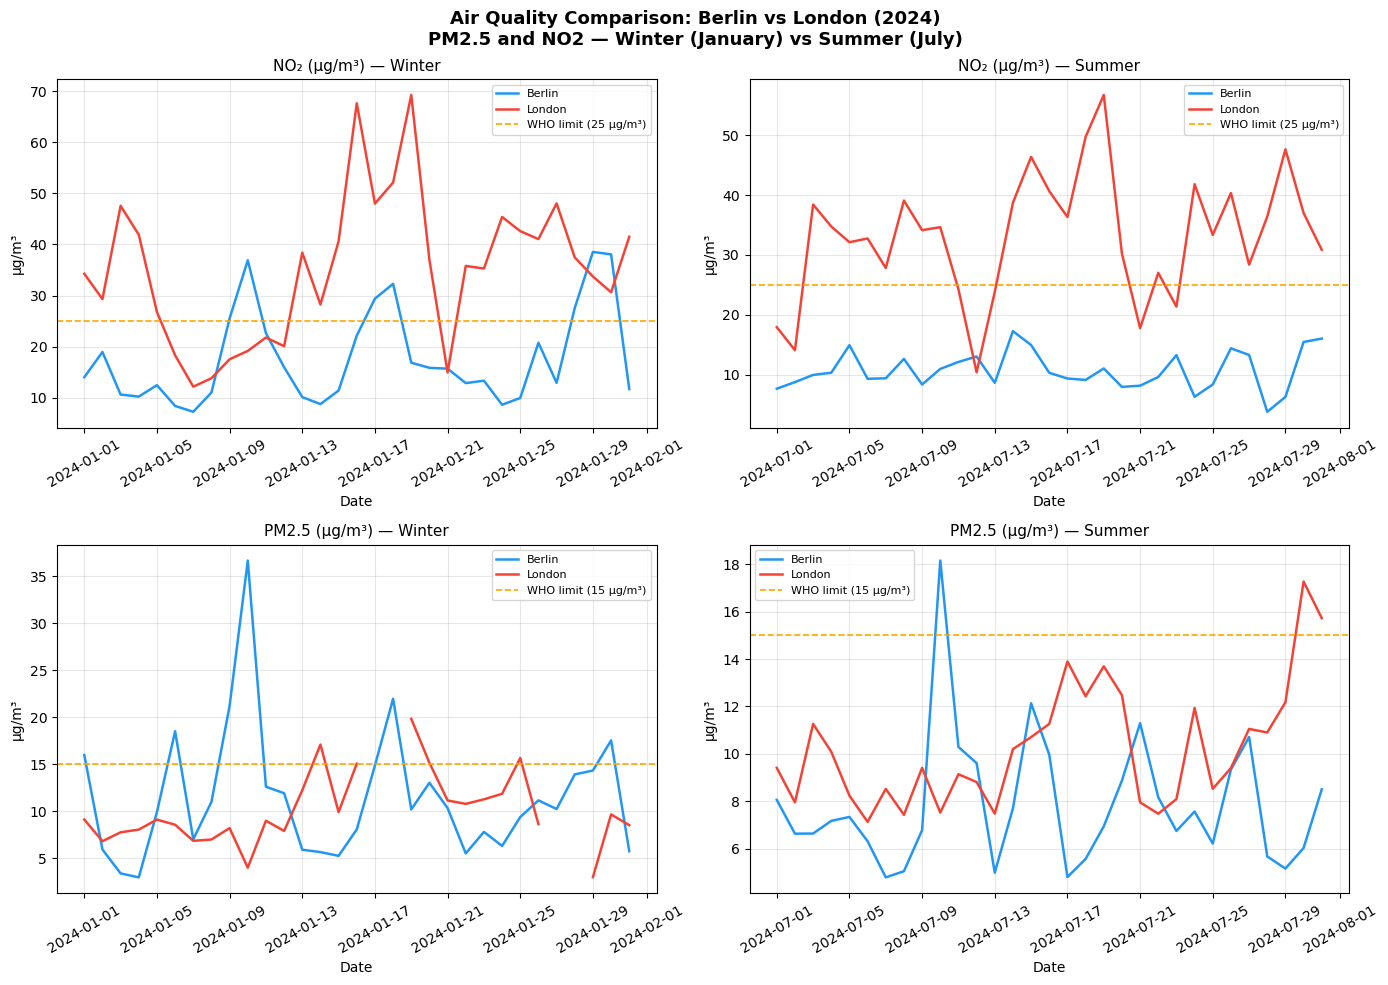

In [37]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Air Quality Comparison: Berlin vs London (2024)\nPM2.5 and NO2 — Winter (January) vs Summer (July)",
    fontsize=13, fontweight="bold"
)

params = ["NO2", "PM25"]
seasons = ["winter", "summer"]
colors = {"Berlin": "#2196F3", "London": "#F44336"}
param_labels = {"NO2": "NO₂ (µg/m³)", "PM25": "PM2.5 (µg/m³)"}
who_limits = {"NO2": 25, "PM25": 15}

for i, param in enumerate(params):
    for j, season in enumerate(seasons):
        ax = axes[i, j]

        for city in ["Berlin", "London"]:
            subset = master_df[
                (master_df["city"] == city) &
                (master_df["parameter"] == param) &
                (master_df["season"] == season)
            ]["value"]

            daily = subset.resample("D").mean()
            ax.plot(daily.index, daily.values,
                    label=city, color=colors[city], linewidth=1.8)

        ax.axhline(who_limits[param], color="orange", linestyle="--",
                   linewidth=1.2, label=f"WHO limit ({who_limits[param]} µg/m³)")

        ax.set_title(f"{param_labels[param]} — {season.capitalize()}", fontsize=11)
        ax.set_ylabel("µg/m³")
        ax.set_xlabel("Date")
        ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=30)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("berlin_london_air_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# Time Series Analysis Interpretation
London NO2 (red) consistently above Berlin (blue) and frequently breaching the WHO limit in both seasons
Berlin NO2 spikes sharply in winter but stays well below London in summer
PM2.5 is more comparable between the two cities, with Berlin showing a notable spike in winter
London PM2.5 is remarkably flat — very stable across both seasons

# Second Visualization: Bar Chart
In this second visualization, we will:
- Set up the fig and axes for our bar chart.
- Define our parameters, the variables that will show us the color to differentiate which plot belongs to which.
- Specify the bar colors as the seasons and specify what colors we want
- We will use the Enumerate function with the for loop and nested for loops to loop through the params , seasons and cities, set the bar's sizes,color and the plot configurations
- set the ax title, labels,ticks, etc
- The bar chart shows the mean pollution levels by cities, parameter(PM2.5 & NO2), and season.

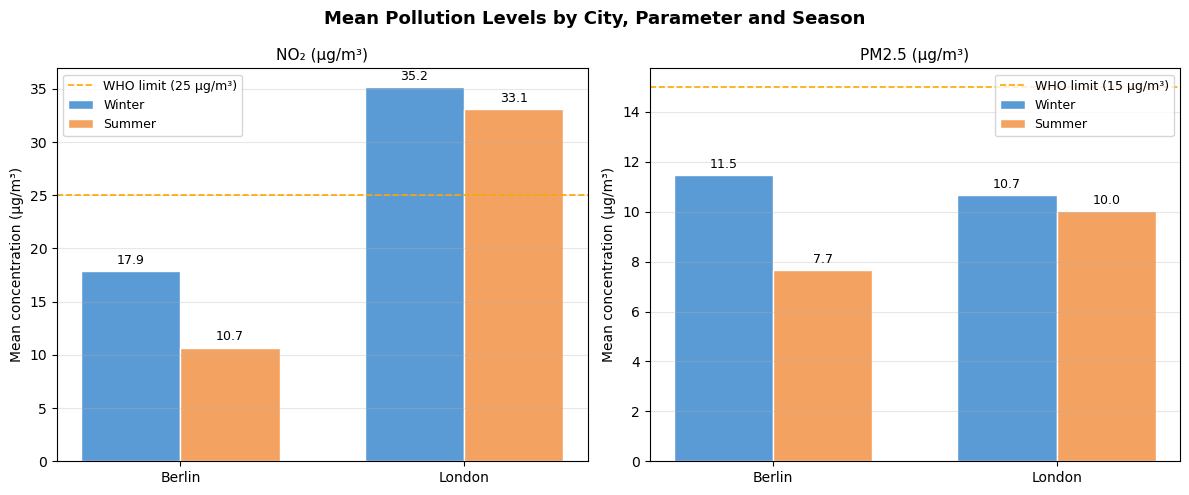

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Mean Pollution Levels by City, Parameter and Season",
    fontsize=13, fontweight="bold"
)

params = ["NO2", "PM25"]
param_labels = {"NO2": "NO₂ (µg/m³)", "PM25": "PM2.5 (µg/m³)"}
who_limits = {"NO2": 25, "PM25": 15}
cities = ["Berlin", "London"]
seasons = ["winter", "summer"]
x = np.arange(len(cities))
width = 0.35
bar_colors = {"winter": "#5B9BD5", "summer": "#F4A261"}

for i, param in enumerate(params):
    ax = axes[i]
    for k, season in enumerate(seasons):
        means = [
            summary.loc[(city, param, season), "mean"]
            for city in cities
        ]
        bars = ax.bar(x + k * width, means, width,
                      label=season.capitalize(),
                      color=bar_colors[season], edgecolor="white")
        ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

    ax.axhline(who_limits[param], color="orange", linestyle="--",
               linewidth=1.2, label=f"WHO limit ({who_limits[param]} µg/m³)")
    ax.set_title(param_labels[param], fontsize=11)
    ax.set_ylabel("Mean concentration (µg/m³)")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(cities)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("berlin_london_bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar Chart Result Interpretation
### NO2
- In the first bar chart, we see that the mean concentration of NO2 in winter in Berlin is almost two times lower than the mean concentration of London.
- The mean concentration of NO2 in summer and winter seasons in London triples the mean concentration of NO2 in Berlin in the same season.
- The difference between the mean concentration of NO2 in Berlin during summer and winter is over half of the mean concentration of NO2 in Berlin during winter, this may be due to high heating emissions, according to Šedivá, T., & Štefánik, D. (2024)
- Surprisingly, the mean concentration of the summer and winter seasons in London is almost the same.
- The bars for London exceeds the WHO limits.
### PM2.5
- In the second bar chart, there is also a mean difference of 3.7 between the mean concentration of PM2.5 in Berlin between the summer and winter seasons.
- While the mean concentration of PM2.5 difference between the summer and winter seasons in London is very low.
- The bar chart also shows that the mean concentration difference of PM2.5 during winter for both London and Berlin is very close in value, while the mean difference for summer is a bit more because London has a mean concentration difference (PM2.5) of 2.3 higher than Berlin.

## Conclusion

This analysis compares PM2.5 and NO2 air quality levels between Berlin (Germany) 
and London (UK) across winter (January 2024) and summer (July 2024) using hourly 
sensor data from the OpenAQ API.

### Key Insights from Visualization and Statiscal Analysis

**NO2: London significantly exceeds Berlin in both seasons**
London recorded mean NO2 levels of 35.2 µg/m³ in winter and 33.1 µg/m³ in summer,
both exceeding the WHO guideline of 25 µg/m³. This may be due to a balancing act in which winter brings more trapped pollutants, while summer triggers intense chemical reactions that recycle the gas (Roncoroni, S., 2021).</br> Berlin remained well below this 
threshold in both seasons (17.9 and 10.7 µg/m³ respectively), and showed stronger 
seasonality, NO2 nearly doubled from summer to winter, likely driven by increased 
heating and reduced atmospheric dispersion in colder months.

**PM2.5: Cities are more comparable, Berlin spikes higher in winter**
PM2.5 levels were broadly similar between cities, with both remaining close to or 
below the WHO 24 hour guideline of 15 µg/m³ on average. However, Berlin showed 
a notably higher winter maximum (109.55 µg/m³) compared to London's (21 µg/m³), 
suggesting occasional acute pollution events, possibly linked to New Year's 
fireworks or cold weather heating emissions. London's PM2.5 was remarkably stable 
across both seasons (std: 2.55 – 3.74), pointing to consistent background levels 
rather than episodic spikes.

### Interpretation

- The most significant finding is London's persistently elevated NO2, which is 
surprising given the city's Ultra Low Emission Zone (ULEZ) introduced in recent 
years. This may reflect the density of traffic at the Westminster Marylebone Road 
monitoring station, one of the busiest roads in the UK and may not be fully 
representative of London as a whole.
- Berlin's lower NO2 levels may reflect both  lower traffic density at the Mitte station and stricter EU vehicle emission standards.

### Limitations

- Data were drawn from single sub-city in each case, Berlin_Mitte, a municipal district in Berlin State and City Of Westminster in London which may not represent 
  city-wide air quality.
- Only two months were analysed (January and July); a full-year dataset would 
  provide stronger seasonal conclusions.

### References
Roncoroni, S. (2021). How COVID-19 lockdowns have affected air quality in London. 
Frontier Economics. https://www.frontier-economics.com/media/kjwl50lv/air-quality-in-london.pdf

Šedivá, T., & Štefánik, D. (2024). The seasonality of PM and NO2 concentrations in 
Slovakia and a comparison with chemical-transport model. Atmosphere, 15(10), 1203. 
https://doi.org/10.3390/atmos15101203